# Stratified Random Sample — FEC Legislators

Takes the matched FEC/legislator CSV and draws a stratified random sample
balanced across **party** and **small-donor quartile**.

Senate is small enough (100 members) that we keep all senators and only
sample from the House.

**Steps**
1. Load matched data
2. Filter & inspect
3. Configure sample size
4. Draw stratified sample
5. Inspect & export

---
## 0 · Imports & config

In [79]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 50)
pd.set_option("display.max_rows", 120)

In [80]:
# ── Paths ───────────────────────────────────────────────────────────────────
MATCHED_CSV  = Path("fec_legislators_matched.csv")
OUTPUT_CSV   = Path("sample.csv")

# ── Sampling config ─────────────────────────────────────────────────────────
RANDOM_SEED  = 22    # change to get a different draw; keep fixed for reproducibility

# How many House members to sample per stratum (party x quartile).
# With 2 parties x 4 quartiles = 8 strata, N_PER_STRATUM=8 gives ~64 House members.
# The actual count may be lower if a stratum has fewer members than requested.
N_PER_STRATUM = 8

# Set to True to keep ALL senators (recommended — only 100 of them).
KEEP_ALL_SENATORS = True

---
## 1 · Load matched data

In [81]:
# ── 1 · Load matched data ────────────────────────────────────────────────────
df = pd.read_csv(MATCHED_CSV)
df["twitter"] = df["twitter"].str.lstrip("@")  # strip any leading @ signs

print(f"Total rows: {len(df)}")
print()
print("Match method breakdown:")
print(df["match_method"].value_counts())
print(df.head())

Total rows: 538

Match method breakdown:
match_method
auto        429
manual      108
no_match      1
Name: count, dtype: int64
                                        Name Total Raised  \
0           TaylorMarjorie Taylor Greene (R)     $7932166   
1  Ocasio-CortezAlexandria Ocasio-Cortez (D)    $15160101   
2                  SandersBernie Sanders (I)    $35728405   
3                       JordanJim Jordan (R)    $13313614   
4                         CraneEli Crane (R)     $8437397   

  Total from Small Donors Percent from Small Donors* total money raised  \
0                $5763400                     72.66%  Raised over $100k   
1               $10602414                     69.94%  Raised over $100k   
2               $22732498                     63.63%  Raised over $100k   
3                $7423207                     55.76%  Raised over $100k   
4                $4638205                     54.97%  Raised over $100k   

  party_code   party_full  Total Raised_num  Total fro

---
## 2 · Filter & inspect

We drop:
- Rows with no bioguide (true non-members / candidates who never served)
- Rows with no `pct_small_donors` (can't stratify without the key variable)
- Members who raised less than $100k (noisy small-donor percentages)

In [82]:
# Keep only matched members
pool = df[df["bioguide"].notna()].copy()
print(f"After dropping non-members: {len(pool)}")

# Drop rows missing the pct column
pool = pool[pool["pct_small_donors"].notna()]
print(f"After dropping missing pct_small_donors: {len(pool)}")

# Drop low fundraisers (noisy percentages)
if "total money raised" in pool.columns:
    pool = pool[pool["total money raised"] == "Raised over $100k"]
    print(f"After dropping <$100k raisers: {len(pool)}")

# Drop rows without a Twitter handle          ← new
pool = pool[pool["twitter"].notna() & (pool["twitter"] != "")]
print(f"After dropping missing Twitter handles: {len(pool)}")

# Normalize party to R/D/I for stratification
pool["party_code"] = pool["party_code"].fillna(
    pool["party"].map({"Republican": "R", "Democrat": "D", "Independent": "I"})
)

print()
print("Pool breakdown:")
print(pool.groupby(["chamber", "party_code"]).size().unstack(fill_value=0))

After dropping non-members: 537
After dropping missing pct_small_donors: 537
After dropping <$100k raisers: 531
After dropping missing Twitter handles: 531

Pool breakdown:
party_code    D  I    R
chamber                
rep         209  0  216
sen          51  3   52


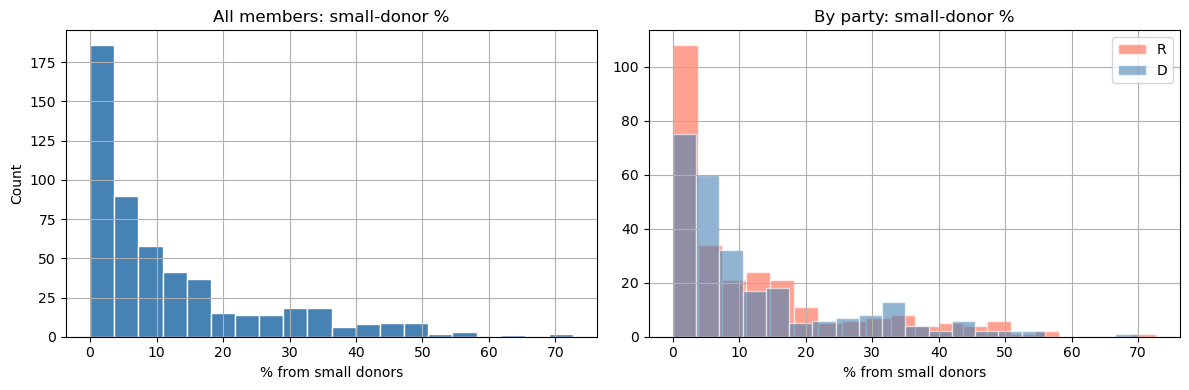

            count  mean   std  min  25%  50%   75%   max
party_code                                              
D           260.0  12.1  13.2  0.0  3.0  6.7  15.6  69.9
I             3.0  26.6  32.1  7.6  8.1  8.5  36.1  63.6
R           268.0  12.1  14.0  0.1  1.9  6.3  17.3  72.7


In [83]:
# Distribution of small-donor % across the pool
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pool["pct_small_donors"].hist(bins=20, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("All members: small-donor %")
axes[0].set_xlabel("% from small donors")
axes[0].set_ylabel("Count")

for party, color in [("R", "tomato"), ("D", "steelblue")]:
    subset = pool[pool["party_code"] == party]["pct_small_donors"]
    subset.hist(bins=20, ax=axes[1], alpha=0.6, label=party, color=color, edgecolor="white")
axes[1].set_title("By party: small-donor %")
axes[1].set_xlabel("% from small donors")
axes[1].legend()

plt.tight_layout()
plt.show()

print(pool.groupby("party_code")["pct_small_donors"].describe().round(1))

---
## 3 · Assign quartiles

Quartiles are computed **within each chamber separately** so House and Senate
members are compared to their own chamber peers, not to each other
(senators generally raise very differently from House members).

In [84]:
def assign_quartiles(group):
    group = group.copy()
    group["quartile"] = pd.qcut(
        group["pct_small_donors"],
        q=4,
        labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"],
        duplicates="drop",
    )
    return group

pool = pool.groupby("chamber", group_keys=False).apply(assign_quartiles)

print("Quartile boundaries by chamber:")
for chamber, grp in pool.groupby("chamber"):
    print(f"  {chamber}:")
    print(grp.groupby("quartile")["pct_small_donors"].agg(["min", "max", "count"]).round(1))
    print()

Quartile boundaries by chamber:
  rep:
               min   max  count
quartile                       
Q1 (lowest)    0.0   1.7    107
Q2             1.7   5.4    106
Q3             5.4  13.3    106
Q4 (highest)  13.4  72.7    106

  sen:
               min   max  count
quartile                       
Q1 (lowest)    0.0   7.6     27
Q2             7.8  18.2     26
Q3            19.5  32.5     26
Q4 (highest)  32.9  63.6     27



---
## 4 · Draw stratified sample

In [85]:
house  = pool[pool["chamber"] == "rep"].copy()
senate = pool[pool["chamber"] == "sen"].copy()

# ── Senate: keep all (or sample if you prefer) ───────────────────────────
if KEEP_ALL_SENATORS:
    senate_sample = senate.copy()
    senate_sample["sample_method"] = "all senators kept"
    print(f"Senators kept: {len(senate_sample)}")
else:
    senate_sample = (
        senate
        .groupby(["party_code", "quartile"], group_keys=False)
        .apply(lambda x: x.sample(min(len(x), N_PER_STRATUM), random_state=RANDOM_SEED))
    )
    senate_sample["sample_method"] = "stratified"
    print(f"Senate sample: {len(senate_sample)}")

# ── House: stratified by party x quartile ────────────────────────────────
house_sample = (
    house
    .groupby(["party_code", "quartile"], group_keys=False)
    .apply(lambda x: x.sample(min(len(x), N_PER_STRATUM), random_state=RANDOM_SEED))
)
house_sample["sample_method"] = "stratified"
print(f"House sample : {len(house_sample)}")

# ── Combine ───────────────────────────────────────────────────────────────
sample = pd.concat([senate_sample, house_sample], ignore_index=True)
print(f"\nTotal sample : {len(sample)}")

Senators kept: 106
House sample : 64

Total sample : 170


---
## 5 · Inspect sample

In [86]:
print("=== Sample composition ===")
print()
print("By chamber x party:")
print(sample.groupby(["chamber", "party_code"]).size().unstack(fill_value=0))
print()
print("House strata counts (party x quartile):")
house_s = sample[sample["chamber"] == "rep"]
print(house_s.groupby(["party_code", "quartile"]).size().unstack(fill_value=0))

=== Sample composition ===

By chamber x party:
party_code   D  I   R
chamber              
rep         32  0  32
sen         51  3  52

House strata counts (party x quartile):
quartile    Q1 (lowest)  Q2  Q3  Q4 (highest)
party_code                                   
D                     8   8   8             8
R                     8   8   8             8


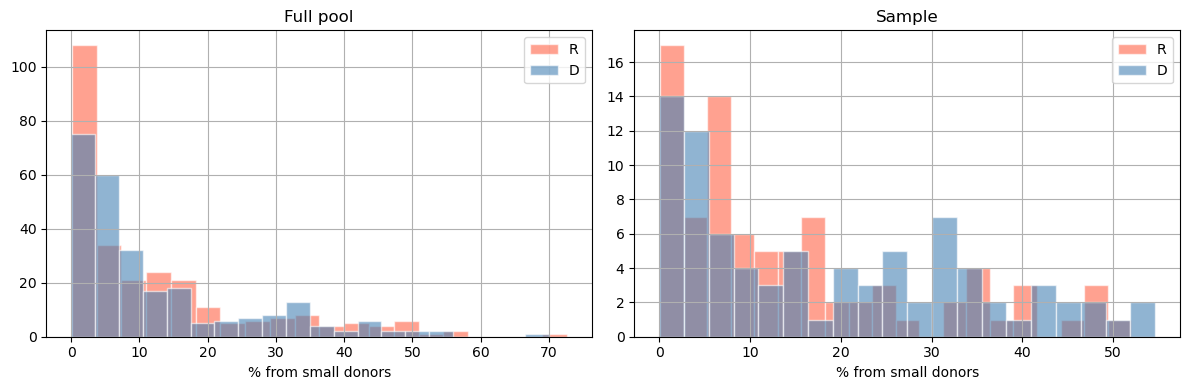

Pool stats:
            count  mean   std  min  25%  50%   75%   max
party_code                                              
D           260.0  12.1  13.2  0.0  3.0  6.7  15.6  69.9
I             3.0  26.6  32.1  7.6  8.1  8.5  36.1  63.6
R           268.0  12.1  14.0  0.1  1.9  6.3  17.3  72.7

Sample stats:
            count  mean   std  min  25%   50%   75%   max
party_code                                               
D            83.0  18.7  15.6  0.0  4.4  15.0  31.5  54.6
I             3.0  26.6  32.1  7.6  8.1   8.5  36.1  63.6
R            84.0  14.8  14.0  0.1  4.1   8.8  20.5  52.0


In [87]:
# Compare pct_small_donors distribution: pool vs sample
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for party, color in [("R", "tomato"), ("D", "steelblue")]:
    pool[pool["party_code"] == party]["pct_small_donors"].hist(
        bins=20, ax=axes[0], alpha=0.6, label=party, color=color, edgecolor="white")
    sample[sample["party_code"] == party]["pct_small_donors"].hist(
        bins=20, ax=axes[1], alpha=0.6, label=party, color=color, edgecolor="white")

axes[0].set_title("Full pool")
axes[1].set_title("Sample")
for ax in axes:
    ax.set_xlabel("% from small donors")
    ax.legend()
plt.tight_layout()
plt.show()

print("Pool stats:")
print(pool.groupby("party_code")["pct_small_donors"].describe().round(1))
print()
print("Sample stats:")
print(sample.groupby("party_code")["pct_small_donors"].describe().round(1))

In [88]:
# Twitter handle coverage — important for your tweet collection step
has_twitter = sample["twitter"].notna() & (sample["twitter"] != "")
print(f"Twitter handles available: {has_twitter.sum()} / {len(sample)} ({100*has_twitter.mean():.0f}%)")
print()
print("Members WITHOUT a twitter handle:")
no_twitter = sample[~has_twitter][["official_full", "chamber", "party_code", "state"]]
print(no_twitter.to_string())


Twitter handles available: 170 / 170 (100%)

Members WITHOUT a twitter handle:
Empty DataFrame
Columns: [official_full, chamber, party_code, state]
Index: []


In [89]:
# Full sample list
sample[["official_full", "twitter", "chamber", "state", "party_code",
        "quartile", "pct_small_donors"]].sort_values(
    ["chamber", "party_code", "quartile"]
)

,official_full,twitter,chamber,state,party_code,quartile,pct_small_donors
106,Richard E. Neal,RepRichardNeal,rep,MA,D,Q1 (lowest),0.14
107,Glenn Ivey,RepGlennIvey,rep,MD,D,Q1 (lowest),1.13
108,Jake Auchincloss,RepAuchincloss,rep,MA,D,Q1 (lowest),0.71
109,Darren Soto,RepDarrenSoto,rep,FL,D,Q1 (lowest),1.43
110,Stephen F. Lynch,RepStephenLynch,rep,MA,D,Q1 (lowest),0.43
...,...,...,...,...,...,...,...
16,Mike Lee,SenMikeLee,sen,UT,R,Q4 (highest),36.49
17,Josh Hawley,SenHawleyPress,sen,MO,R,Q4 (highest),36.38
18,Marco Rubio,marcorubio,sen,FL,R,Q4 (highest),36.30
20,Steve Daines,SteveDaines,sen,MT,R,Q4 (highest),35.75


---
## 6 · Export

In [90]:
sample.to_csv(OUTPUT_CSV, index=False)
print(f"Saved → {OUTPUT_CSV}  ({len(sample)} rows)")
print(f"Seed used: {RANDOM_SEED}  — change RANDOM_SEED in cell 0 for a different draw")

Saved → sample.csv  (170 rows)
Seed used: 22  — change RANDOM_SEED in cell 0 for a different draw


In [91]:
# ── 7 · Export chamber-split CSVs ────────────────────────────────────────────
HOUSE_CSV  = Path("sample_house.csv")
SENATE_CSV = Path("sample_senate.csv")

sample_house  = sample[sample["chamber"] == "rep"].copy()
sample_senate = sample[sample["chamber"] == "sen"].copy()

sample_house.to_csv(HOUSE_CSV, index=False)
print(f"Saved → {HOUSE_CSV}  ({len(sample_house)} rows)")

sample_senate.to_csv(SENATE_CSV, index=False)
print(f"Saved → {SENATE_CSV}  ({len(sample_senate)} rows)")

Saved → sample_house.csv  (64 rows)
Saved → sample_senate.csv  (106 rows)


In [ ]:
# ── Draw 4 replacement House members ────────────────────────────────────────
sample_house = pd.read_csv("sample_house.csv")

already_sampled = set(sample_house["bioguide"].dropna())

rep_pool = pool[
    (pool["chamber"] == "rep") &
    (~pool["bioguide"].isin(already_sampled)) &
    pool["twitter"].notna() & (pool["twitter"] != "")
].copy()

replacements_needed = [
    ("Q1 (lowest)", "R"),  # Rogers
    ("Q1 (lowest)", "R"),  # Gooden
    ("Q3",          "D"),  # Cartwright
    ("Q3",          "R"),  # Posey
]

new_members = []
for quartile, party in replacements_needed:
    stratum = rep_pool[
        (rep_pool["quartile"]   == quartile) &
        (rep_pool["party_code"] == party)
    ]
    chosen = stratum.sample(n=1, random_state=RANDOM_SEED)
    chosen = chosen.copy()
    chosen["sample_method"] = "replacement"
    new_members.append(chosen)
    rep_pool = rep_pool[rep_pool["bioguide"] != chosen["bioguide"].iloc[0]]
    print(f"{quartile} {party} → {chosen['official_full'].iloc[0]} ({chosen['twitter'].iloc[0]})")

new_members_df = pd.concat(new_members, ignore_index=True)
sample_house_updated = pd.concat([sample_house, new_members_df], ignore_index=True)
sample_house_updated.to_csv("sample_house.csv", index=False)
print(f"\nAppended 4 members. New total: {len(sample_house_updated)}")